In [1]:
import sys
from pathlib import Path

raiz = Path.cwd()
if raiz.name == "notebooks":
    raiz = raiz.parent
sys.path.insert(0, str(raiz))

from lakehouse import Lakehouse

db = Lakehouse()
catalogo = db.catalogo

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

figuras = raiz / 'figuras'
figuras.mkdir(exist_ok=True)

In [2]:
# 1. Traer TODOS los partos únicos, agregados por combinación de variables
# Cada fila es una combinación con su número de nacimientos; ese conteo se usa como
# sample_weight, lo que equivale a entrenar con los ~4.8 millones de registros.
# El establecimiento (IPRESS) entra como su tasa de bajo peso en 2015-2023, suavizada hacia
# la media nacional (200 nacimientos de peso): no usa información de 2024 ni de 2025.
FILTRO = "anio_nacimiento BETWEEN 2015 AND 2025 AND es_registro_analisis"
consulta_modelo = f"""
WITH base AS (
  SELECT * FROM __CATALOGO__.curated.nacimientos_peru WHERE {FILTRO}
), establecimientos AS (
  SELECT codigo_ipress, COUNT(*) AS n, COUNT_IF(es_bajo_peso_nacer) AS casos
  FROM base
  WHERE anio_nacimiento <= 2023 AND codigo_ipress IS NOT NULL
  GROUP BY codigo_ipress
), nacional AS (
  SELECT AVG(CAST(es_bajo_peso_nacer AS INT)) AS p0 FROM base WHERE anio_nacimiento <= 2023
)
SELECT b.anio_nacimiento,
       CAST(b.es_bajo_peso_nacer AS INT) AS bajo_peso,
       CASE WHEN b.es_edad_madre_valida THEN b.edad_madre END AS edad_madre,
       COALESCE(b.nivel_instruccion_madre, 'SIN DATO') AS nivel_instruccion_madre,
       COALESCE(b.estado_civil, 'SIN DATO') AS estado_civil,
       COALESCE(b.num_embar_madre_cat, 'SIN DATO') AS num_embar_madre_cat,
       COALESCE(b.hijos_vivos_madre_cat, 'SIN DATO') AS hijos_vivos_madre_cat,
       COALESCE(b.hijos_fallecidos_madre_cat, 'SIN DATO') AS hijos_fallecidos_madre_cat,
       COALESCE(b.antecedentes_abortos_cat, 'SIN DATO') AS antecedentes_abortos_cat,
       COALESCE(b.financiador_parto, 'SIN DATO') AS financiador_parto,
       COALESCE(b.pais_madre_grupo, 'SIN DATO') AS pais_madre_grupo,
       COALESCE(b.sexo_nacido, 'SIN DATO') AS sexo_nacido,
       COALESCE(b.departamento_residencia, 'SIN DATO') AS departamento_residencia,
       COALESCE(b.macroregion, 'SIN DATO') AS macroregion,
       b.altitud_msnm, b.idh_2019, b.pobreza_pct, b.vulnerabilidad_alimentaria,
       ROUND((COALESCE(e.casos, 0) + 200 * n.p0) / (COALESCE(e.n, 0) + 200), 4) AS tasa_bajo_peso_establecimiento,
       COALESCE(b.lugar_nacido, 'SIN DATO') AS lugar_nacido,
       COALESCE(b.atiende_parto, 'SIN DATO') AS atiende_parto,
       b.duracion_embarazo_semanas,
       COUNT(*) AS nacimientos
FROM base b
LEFT JOIN establecimientos e ON b.codigo_ipress = e.codigo_ipress
CROSS JOIN nacional n
GROUP BY ALL
"""
datos = db.consultar(consulta_modelo, categorias=True)
total = db.consultar(f"SELECT COUNT(*) AS n FROM __CATALOGO__.curated.nacimientos_peru WHERE {FILTRO}")
assert int(datos['nacimientos'].sum()) == int(total.loc[0, 'n'])
for columna in ['edad_madre', 'altitud_msnm', 'idh_2019', 'pobreza_pct', 'vulnerabilidad_alimentaria',
                'tasa_bajo_peso_establecimiento', 'duracion_embarazo_semanas']:
    datos[columna] = pd.to_numeric(datos[columna], errors='coerce')
print(f"{len(datos):,} combinaciones que representan {datos['nacimientos'].sum():,} nacimientos")

por_anio = (datos.assign(casos=datos['bajo_peso'] * datos['nacimientos'])
                 .groupby('anio_nacimiento')[['nacimientos', 'casos']].sum())
por_anio['% bajo peso'] = (100 * por_anio['casos'] / por_anio['nacimientos']).round(2)
print(por_anio.to_string())

4,692,425 combinaciones que representan 4,805,234 nacimientos
                 nacimientos  casos  % bajo peso
anio_nacimiento                                 
2015                  408930  22205         5.43
2016                  450833  23851         5.29
2017                  470716  24366         5.18
2018                  484228  24693         5.10
2019                  475658  25045         5.27
2020                  452454  23175         5.12
2021                  453068  24797         5.47
2022                  456170  25604         5.61
2023                  401916  23984         5.97
2024                  381956  22486         5.89
2025                  369305  21643         5.86


In [3]:
# 2. Definir capas de información y separar por año (2015-2023 / 2024 / 2025)
# Cada capa agrega información que se conoce más tarde. Las capas 1-2 son el escenario prenatal
# (tamizaje antes del parto); las 3-4 usan datos del parto: discriminan más, pero el establecimiento
# refleja la derivación de embarazos de riesgo y las semanas de gestación son parte del mecanismo.
CAPAS = {}
numericas, categoricas = ['edad_madre'], ['nivel_instruccion_madre', 'estado_civil', 'num_embar_madre_cat',
                                          'hijos_vivos_madre_cat', 'hijos_fallecidos_madre_cat',
                                          'antecedentes_abortos_cat', 'financiador_parto',
                                          'pais_madre_grupo', 'sexo_nacido']
CAPAS['1. Prenatal: madre y hogar'] = (list(numericas), list(categoricas))
numericas += ['altitud_msnm', 'idh_2019', 'pobreza_pct', 'vulnerabilidad_alimentaria']
categoricas += ['departamento_residencia', 'macroregion']
CAPAS['2. Prenatal: + territorio'] = (list(numericas), list(categoricas))
CAPAS['3. Al parto: + establecimiento y atención'] = (numericas + ['tasa_bajo_peso_establecimiento'],
                                            categoricas + ['lugar_nacido', 'atiende_parto'])
CAPA_SEMANAS = '4. Al parto: + semanas de gestación'
CAPAS[CAPA_SEMANAS] = (CAPAS['3. Al parto: + establecimiento y atención'][0] + ['duracion_embarazo_semanas'],
                       CAPAS['3. Al parto: + establecimiento y atención'][1])
ESCENARIO_PRENATAL = '2. Prenatal: + territorio'
numericas, categoricas = CAPAS[ESCENARIO_PRENATAL]
variables = numericas + categoricas


def partir(condicion):
    parte = datos[condicion]
    return parte, parte['bajo_peso'].to_numpy(), parte['nacimientos'].to_numpy(float)


D_ent, y_ent, w_ent = partir(datos['anio_nacimiento'] <= 2023)
D_val, y_val, w_val = partir(datos['anio_nacimiento'] == 2024)
D_pru, y_pru, w_pru = partir(datos['anio_nacimiento'] == 2025)
X_ent, X_val, X_pru = D_ent[variables], D_val[variables], D_pru[variables]
for nombre, y, w in [('Entrenamiento', y_ent, w_ent), ('Validación', y_val, w_val), ('Prueba', y_pru, w_pru)]:
    print(f'{nombre}: {w.sum():,.0f} nacimientos, bajo peso {100 * (w * y).sum() / w.sum():.2f} %')

Entrenamiento: 4,053,973 nacimientos, bajo peso 5.37 %
Validación: 381,956 nacimientos, bajo peso 5.89 %
Prueba: 369,305 nacimientos, bajo peso 5.86 %


Asociación de cada variable con el bajo peso y la prematuridad:
                                bajo_peso  prematuro
tasa_bajo_peso_establecimiento      0.152      0.162
atiende_parto                       0.083      0.128
departamento_residencia             0.048      0.033
edad_madre                          0.038      0.043
macroregion                         0.036      0.030
financiador_parto                   0.033      0.039
estado_civil                        0.033      0.028
hijos_vivos_madre_cat               0.031      0.014
nivel_instruccion_madre             0.030      0.020
idh_2019                            0.030      0.021
num_embar_madre_cat                 0.029      0.021
vulnerabilidad_alimentaria          0.027      0.020
pobreza_pct                         0.026      0.018
altitud_msnm                        0.022      0.032
hijos_fallecidos_madre_cat          0.020      0.022
lugar_nacido                        0.014      0.011
pais_madre_grupo                   

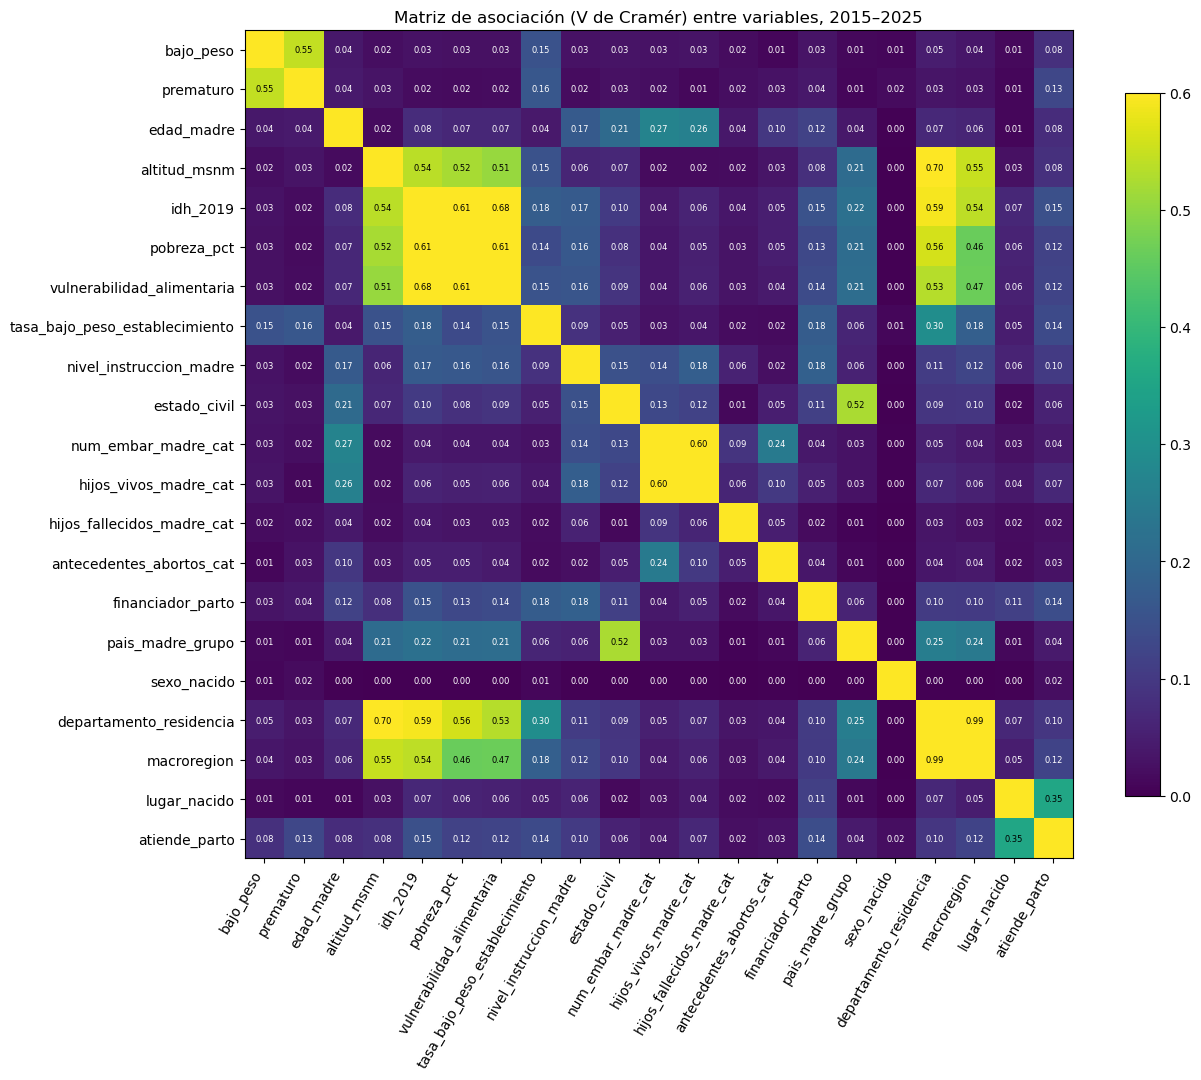

In [4]:
# 2b. Matriz de asociación entre variables (V de Cramér, ponderada por nacimientos)
# Todas las variables de las capas más el bajo peso y la prematuridad; las numéricas en quintiles.
# V va de 0 (sin asociación) a 1; muestra redundancias (colinealidad) y qué se asocia al resultado.
def codigos(serie):
    # int64: los códigos de pandas son int8 y se desbordarían al combinarlos en v_cramer
    if isinstance(serie.dtype, pd.CategoricalDtype):
        return serie.cat.codes.to_numpy().astype(np.int64) + 1
    return pd.qcut(serie, 5, labels=False, duplicates='drop').fillna(-1).to_numpy(np.int64) + 1


def v_cramer(a, b, w):
    tabla = np.bincount(a * (b.max() + 1) + b, weights=w, minlength=(a.max() + 1) * (b.max() + 1))
    tabla = tabla.reshape(a.max() + 1, b.max() + 1)
    tabla = tabla[tabla.sum(axis=1) > 0][:, tabla.sum(axis=0) > 0]
    esperado = np.outer(tabla.sum(axis=1), tabla.sum(axis=0)) / tabla.sum()
    chi2 = ((tabla - esperado) ** 2 / esperado).sum()
    return np.sqrt(chi2 / (tabla.sum() * (min(tabla.shape) - 1)))


todas = CAPAS[CAPA_SEMANAS][0] + CAPAS[CAPA_SEMANAS][1]
columnas_asociacion = {'bajo_peso': datos['bajo_peso'].to_numpy(np.int64) + 1,
                       'prematuro': (datos['duracion_embarazo_semanas'] < 37).to_numpy(np.int64) + 1}
columnas_asociacion.update({c: codigos(datos[c]) for c in todas if c != 'duracion_embarazo_semanas'})
pesos = datos['nacimientos'].to_numpy(float)
nombres = list(columnas_asociacion)
asociacion = pd.DataFrame(np.eye(len(nombres)), index=nombres, columns=nombres)
for i, a in enumerate(nombres):
    for b in nombres[i + 1:]:
        asociacion.loc[a, b] = asociacion.loc[b, a] = v_cramer(columnas_asociacion[a], columnas_asociacion[b], pesos)
print('Asociación de cada variable con el bajo peso y la prematuridad:')
print(asociacion[['bajo_peso', 'prematuro']].drop(['bajo_peso', 'prematuro'])
      .sort_values('bajo_peso', ascending=False).round(3).to_string())

fig, ax = plt.subplots(figsize=(13, 11))
imagen = ax.imshow(asociacion, cmap='viridis', vmin=0, vmax=0.6)
ax.set_xticks(range(len(nombres)), nombres, rotation=60, ha='right')
ax.set_yticks(range(len(nombres)), nombres)
for (i, j), valor in np.ndenumerate(asociacion.to_numpy()):
    if i != j:
        ax.text(j, i, f'{valor:.2f}', ha='center', va='center', fontsize=6,
                color='white' if valor < 0.35 else 'black')
ax.set_title('Matriz de asociación (V de Cramér) entre variables, 2015–2025')
plt.colorbar(imagen, ax=ax, shrink=0.8)
fig.tight_layout()
fig.savefig(figuras / 'matriz_asociacion.png', dpi=180)
plt.show()

In [5]:
# 3. Definir los modelos candidatos
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, brier_score_loss, log_loss, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, SplineTransformer, StandardScaler


def regresion_logistica(C, numericas, categoricas):
    # La edad entra como curva (splines): el riesgo tiene forma de U, no es lineal
    otras = [c for c in numericas if c != 'edad_madre']
    preparar = ColumnTransformer([
        ('edad', Pipeline([('imputar', SimpleImputer(strategy='median')),
                           ('curva', SplineTransformer(n_knots=6, degree=3))]), ['edad_madre']),
        ('contexto', Pipeline([('imputar', SimpleImputer(strategy='median')),
                               ('escalar', StandardScaler())]), otras),
        ('categorias', OneHotEncoder(handle_unknown='ignore'), categoricas),
    ])
    return Pipeline([('preparar', preparar),
                     ('clasificar', LogisticRegression(C=C, max_iter=2000))])


def gradient_boosting(tasa, hojas):
    # Árboles potenciados: capturan interacciones (p. ej. edad × altitud) sin especificarlas
    return HistGradientBoostingClassifier(learning_rate=tasa, max_leaf_nodes=hojas, max_iter=1000,
                                          l2_regularization=1.0, categorical_features='from_dtype',
                                          early_stopping=True, validation_fraction=0.1,
                                          n_iter_no_change=20, random_state=42)


def ajustar(modelo, X, y, w):
    if isinstance(modelo, Pipeline):
        return modelo.fit(X, y, clasificar__sample_weight=w)
    return modelo.fit(X, y, sample_weight=w)


def evaluar(y, prob, w):
    """Métricas que no dependen de un umbral: discriminación, ajuste y calibración."""
    prevalencia = (w * y).sum() / w.sum()
    brier = brier_score_loss(y, prob, sample_weight=w)
    logit = np.log(prob / (1 - prob)).reshape(-1, 1)
    recalibracion = LogisticRegression(C=1e6).fit(logit, y, sample_weight=w)
    return {'roc_auc': roc_auc_score(y, prob, sample_weight=w),
            'average_precision': average_precision_score(y, prob, sample_weight=w),
            'log_loss': log_loss(y, prob, sample_weight=w),
            'brier': brier,
            # 1 - Brier / Brier de predecir siempre la prevalencia: >0 mejora sobre no usar modelo
            'brier_skill': 1 - brier / (prevalencia * (1 - prevalencia)),
            'observados/esperados': (w * y).sum() / (w * prob).sum(),
            'pendiente_calibracion': recalibracion.coef_[0, 0]}


candidatos = {
    'Logística C=1': regresion_logistica(1.0, numericas, categoricas),
    'Boosting tasa=0.1 hojas=31': gradient_boosting(0.1, 31),
    'Boosting tasa=0.05 hojas=63': gradient_boosting(0.05, 63),
}

In [6]:
# 4. Escenario prenatal (bajo peso): ajustar en 2015-2023 y elegir con 2024 (menor log loss = mejor ajuste)
resultados = []
for nombre, modelo in candidatos.items():
    ajustar(modelo, X_ent, y_ent, w_ent)
    resultados.append({'modelo': nombre, **evaluar(y_val, modelo.predict_proba(X_val)[:, 1], w_val)})
validacion = pd.DataFrame(resultados).sort_values('log_loss')
print(validacion.round(4).to_string(index=False))

mejor = validacion.iloc[0]['modelo']
mejor_logistica = 'Logística C=1'
print('Mejor modelo en validación:', mejor)

                     modelo  roc_auc  average_precision  log_loss  brier  brier_skill  observados/esperados  pendiente_calibracion
 Boosting tasa=0.1 hojas=31   0.6249             0.0963    0.2183 0.0547       0.0122                1.0824                 1.0326
Boosting tasa=0.05 hojas=63   0.6246             0.0960    0.2184 0.0547       0.0121                1.0819                 1.0517
              Logística C=1   0.6128             0.0896    0.2195 0.0549       0.0092                1.0786                 1.0922
Mejor modelo en validación: Boosting tasa=0.1 hojas=31


modelo                      Base: prevalencia de entrenamiento  Logística C=1  Boosting tasa=0.1 hojas=31
roc_auc                                                 0.5000         0.6147                      0.6269
average_precision                                       0.0586         0.0889                      0.0948
log_loss                                                0.2233         0.2187                      0.2176
brier                                                   0.0552         0.0547                      0.0545
brier_skill                                            -0.0004         0.0092                      0.0119
observados/esperados                                    1.0912         1.0777                      1.0823
pendiente_calibracion                                   0.8629         1.0973                      1.0305
marcados_%_top10                                           NaN         9.8385                     10.0537
sensibilidad_top10                            

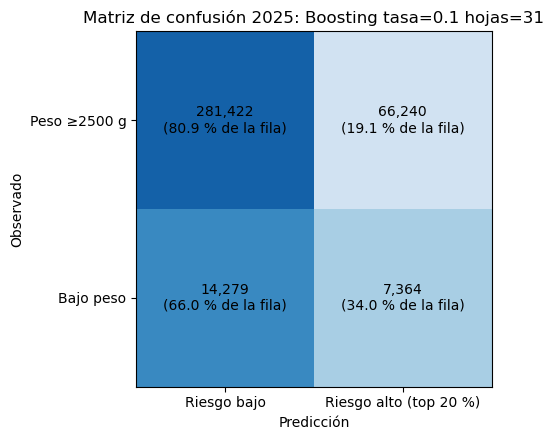

In [7]:
# 5. Escenario prenatal (bajo peso): evaluar una sola vez en 2025
def umbral_top(prob, w, fraccion):
    """Umbral que marca a la fracción de nacimientos con mayor riesgo."""
    orden = np.argsort(-prob)
    acumulado = np.cumsum(w[orden]) / w.sum()
    return prob[orden][np.searchsorted(acumulado, fraccion)]


def confusion(y, prob, w, umbral):
    marcados = prob >= umbral
    return {'VP': (w * y * marcados).sum(), 'FP': (w * (1 - y) * marcados).sum(),
            'FN': (w * y * ~marcados).sum(), 'VN': (w * (1 - y) * ~marcados).sum()}


def metricas_umbral(y, prob, w, umbral):
    """Métricas de clasificación al marcar como riesgo a quienes superan el umbral."""
    c = confusion(y, prob, w, umbral)
    vp, fp, fn, vn = c['VP'], c['FP'], c['FN'], c['VN']
    sensibilidad, especificidad = vp / (vp + fn), vn / (vn + fp)
    vpp, vpn = vp / (vp + fp), vn / (vn + fn)
    return {'marcados_%': 100 * (vp + fp) / w.sum(),
            'sensibilidad': sensibilidad, 'especificidad': especificidad, 'VPP': vpp, 'VPN': vpn,
            'F1': 2 * vpp * sensibilidad / (vpp + sensibilidad),
            'exactitud_balanceada': (sensibilidad + especificidad) / 2,
            'MCC': (vp * vn - fp * fn) / np.sqrt((vp + fp) * (vp + fn) * (vn + fp) * (vn + fn)),
            'LR+': sensibilidad / (1 - especificidad)}


prevalencia_ent = (w_ent * y_ent).sum() / w_ent.sum()
umbrales = {}
filas = [{'modelo': 'Base: prevalencia de entrenamiento',
          **evaluar(y_pru, np.full(len(y_pru), prevalencia_ent), w_pru)}]
probabilidades = {}
for nombre in dict.fromkeys([mejor_logistica, mejor]):
    modelo = candidatos[nombre]
    prob_val = modelo.predict_proba(X_val)[:, 1]
    probabilidades[nombre] = modelo.predict_proba(X_pru)[:, 1]
    fila = {'modelo': nombre, **evaluar(y_pru, probabilidades[nombre], w_pru)}
    for top in (0.10, 0.20):
        # El umbral se fija con 2024 y se aplica sin cambios a 2025
        umbrales[nombre, top] = umbral_top(prob_val, w_val, top)
        punto = metricas_umbral(y_pru, probabilidades[nombre], w_pru, umbrales[nombre, top])
        fila.update({f'{clave}_top{int(top * 100)}': valor for clave, valor in punto.items()})
    filas.append(fila)
metricas = pd.DataFrame(filas).set_index('modelo')
print(metricas.round(4).T.to_string())

# Matriz de confusión del mejor modelo marcando al 20 % de mayor riesgo
c = confusion(y_pru, probabilidades[mejor], w_pru, umbrales[mejor, 0.20])
matriz = np.array([[c['VN'], c['FP']], [c['FN'], c['VP']]])
fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.imshow(matriz / matriz.sum(axis=1, keepdims=True), cmap='Blues', vmin=0, vmax=1)
for (i, j), valor in np.ndenumerate(matriz):
    ax.text(j, i, f'{valor:,.0f}\n({100 * valor / matriz[i].sum():.1f} % de la fila)', ha='center', va='center')
ax.set_xticks([0, 1], ['Riesgo bajo', 'Riesgo alto (top 20 %)'])
ax.set_yticks([0, 1], ['Peso ≥2500 g', 'Bajo peso'])
ax.set(title=f'Matriz de confusión 2025: {mejor}', xlabel='Predicción', ylabel='Observado')
fig.tight_layout()
fig.savefig(figuras / 'matriz_confusion.png', dpi=180)
plt.show()

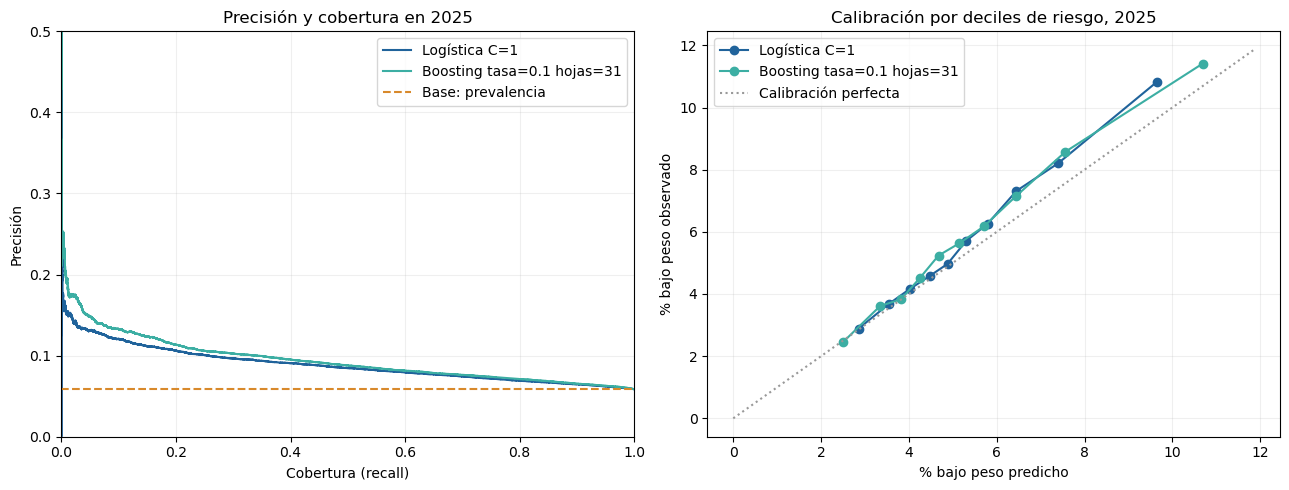

       nacimientos  predicho_%  observado_%
decil                                      
1          36930.0        2.51         2.46
2          36930.0        3.34         3.61
3          36931.0        3.82         3.83
4          36930.0        4.25         4.51
5          36931.0        4.67         5.24
6          36930.0        5.15         5.63
7          36931.0        5.71         6.18
8          36930.0        6.45         7.16
9          36931.0        7.57         8.58
10         36931.0       10.69        11.41


In [8]:
# 6. Graficar precisión-cobertura y calibración en 2025
from sklearn.metrics import precision_recall_curve


def calibracion(y, prob, w, grupos=10):
    orden = np.argsort(prob)
    acumulado = np.cumsum(w[orden]) / w.sum()
    decil = np.empty(len(prob), dtype=int)
    decil[orden] = np.minimum((acumulado * grupos).astype(int), grupos - 1)
    tabla = pd.DataFrame({'decil': decil + 1, 'n': w, 'casos': w * y, 'esperados': w * prob}).groupby('decil').sum()
    return pd.DataFrame({'nacimientos': tabla['n'],
                         'predicho_%': 100 * tabla['esperados'] / tabla['n'],
                         'observado_%': 100 * tabla['casos'] / tabla['n']})


fig, (ax_pr, ax_cal) = plt.subplots(1, 2, figsize=(13, 5))
colores = ['#20639B', '#3CAEA3']
for color, (nombre, prob) in zip(colores, probabilidades.items()):
    precision_t, recall_t, _ = precision_recall_curve(y_pru, prob, sample_weight=w_pru)
    ax_pr.plot(recall_t, precision_t, color=color, label=nombre)
    tabla_cal = calibracion(y_pru, prob, w_pru)
    ax_cal.plot(tabla_cal['predicho_%'], tabla_cal['observado_%'], marker='o', color=color, label=nombre)
ax_pr.axhline((w_pru * y_pru).sum() / w_pru.sum(), color='#D8892B', linestyle='--', label='Base: prevalencia')
ax_pr.set(title='Precisión y cobertura en 2025', xlabel='Cobertura (recall)', ylabel='Precisión',
          xlim=(0, 1), ylim=(0, 0.5))
limite = max(ax_cal.get_xlim()[1], ax_cal.get_ylim()[1])
ax_cal.plot([0, limite], [0, limite], color='#999999', linestyle=':', label='Calibración perfecta')
ax_cal.set(title='Calibración por deciles de riesgo, 2025', xlabel='% bajo peso predicho',
           ylabel='% bajo peso observado')
for ax in (ax_pr, ax_cal):
    ax.legend()
    ax.grid(alpha=0.2)
fig.tight_layout()
fig.savefig(figuras / 'precision_cobertura_modelo.png', dpi=180)
plt.show()
print(calibracion(y_pru, probabilidades[mejor], w_pru).round(2).to_string())

                                                                             roc_auc  average_precision  brier_skill  observados/esperados  sensibilidad_top20  especificidad_top20  VPP_top20  MCC_top20  LR+_top20
resultado                         capa                                                                                                                                                                              
Bajo peso (<2500 g)               1. Prenatal: madre y hogar                   0.607              0.087        0.008                 1.096               0.313                0.808      0.092      0.071      1.632
                                  2. Prenatal: + territorio                    0.627              0.095        0.012                 1.082               0.340                0.809      0.100      0.088      1.786
                                  3. Al parto: + establecimiento y atención    0.734              0.165        0.051                 1.047          

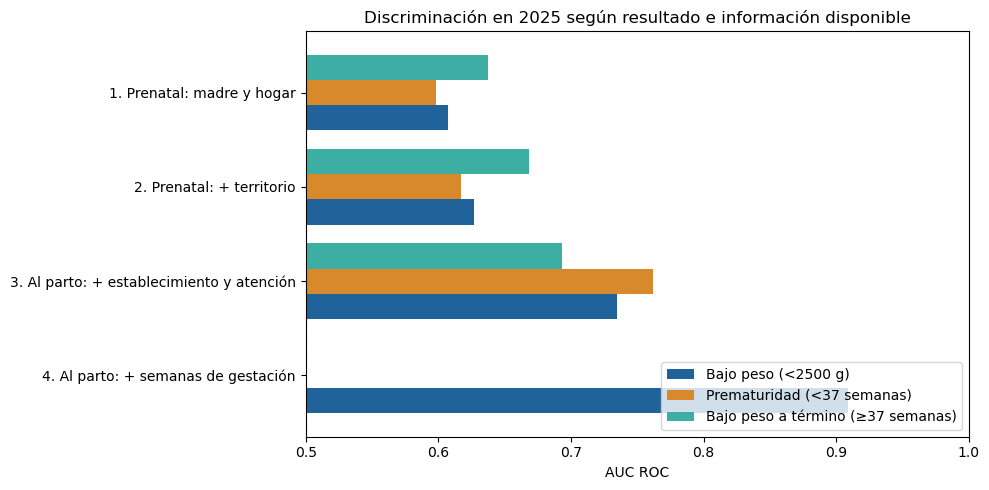

In [9]:
# 7. Tres resultados × momentos de información: ¿cuánto se puede anticipar cada mecanismo?
# El bajo peso tiene dos mecanismos: nacer antes (prematuridad) o crecer menos (bajo peso a término).
# Para esos dos no se usa la capa 4, porque las semanas de gestación definen el propio resultado.
from sklearn.base import clone

configuracion = candidatos[mejor] if mejor.startswith('Boosting') else candidatos['Boosting tasa=0.1 hojas=31']
datos['prematuro'] = (datos['duracion_embarazo_semanas'] < 37).astype(int)
RESULTADOS = {  # nombre: (columna del resultado, solo nacidos a término)
    'Bajo peso (<2500 g)': ('bajo_peso', False),
    'Prematuridad (<37 semanas)': ('prematuro', False),
    'Bajo peso a término (≥37 semanas)': ('bajo_peso', True),
}


def partes_resultado(columna, solo_termino):
    sub = datos[datos['duracion_embarazo_semanas'] >= 37] if solo_termino else datos
    return {nombre: (sub[condicion], sub.loc[condicion, columna].to_numpy(),
                     sub.loc[condicion, 'nacimientos'].to_numpy(float))
            for nombre, condicion in [('ent', sub['anio_nacimiento'] <= 2023),
                                      ('val', sub['anio_nacimiento'] == 2024),
                                      ('pru', sub['anio_nacimiento'] == 2025)]}


por_capa, prenatales = [], {}
for resultado, (columna, solo_termino) in RESULTADOS.items():
    partes = partes_resultado(columna, solo_termino)
    (D_e, y_e, w_e), (D_v, y_v, w_v), (D_p, y_p, w_p) = partes['ent'], partes['val'], partes['pru']
    for capa, (num, cat) in CAPAS.items():
        if capa == CAPA_SEMANAS and resultado != 'Bajo peso (<2500 g)':
            continue
        modelo_capa = ajustar(clone(configuracion), D_e[num + cat], y_e, w_e)
        prob = modelo_capa.predict_proba(D_p[num + cat])[:, 1]
        umbral = umbral_top(modelo_capa.predict_proba(D_v[num + cat])[:, 1], w_v, 0.20)
        por_capa.append({'resultado': resultado, 'capa': capa, **evaluar(y_p, prob, w_p),
                         **{f'{k}_top20': v for k, v in metricas_umbral(y_p, prob, w_p, umbral).items()}})
        if capa == ESCENARIO_PRENATAL:
            prenatales[resultado] = (modelo_capa, partes)
por_capa = pd.DataFrame(por_capa)
columnas_resumen = ['roc_auc', 'average_precision', 'brier_skill', 'observados/esperados',
                    'sensibilidad_top20', 'especificidad_top20', 'VPP_top20', 'MCC_top20', 'LR+_top20']
print(por_capa.set_index(['resultado', 'capa'])[columnas_resumen].round(3).to_string())

fig, ax = plt.subplots(figsize=(10, 5))
tabla_auc = por_capa.pivot(index='capa', columns='resultado', values='roc_auc')[list(RESULTADOS)]
tabla_auc.iloc[::-1].plot.barh(ax=ax, color=['#20639B', '#D8892B', '#3CAEA3'], width=0.8)
ax.axvline(0.5, color='#999999', linestyle=':')
ax.set(title='Discriminación en 2025 según resultado e información disponible', xlabel='AUC ROC',
       ylabel='', xlim=(0.5, 1))
ax.legend(loc='lower right')
fig.tight_layout()
fig.savefig(figuras / 'auc_por_capa.png', dpi=180)
plt.show()

                            Bajo peso (<2500 g)  Prematuridad (<37 semanas)  Bajo peso a término (≥37 semanas)
hijos_vivos_madre_cat                   0.00699                     0.00446                            0.00104
num_embar_madre_cat                     0.00344                     0.00147                            0.00082
financiador_parto                       0.00300                     0.00348                            0.00056
departamento_residencia                 0.00278                     0.00217                            0.00244
edad_madre                              0.00250                     0.00316                            0.00044
altitud_msnm                            0.00135                     0.00052                            0.00086
nivel_instruccion_madre                 0.00079                     0.00044                            0.00099
pais_madre_grupo                        0.00059                     0.00035                            0.00021
h

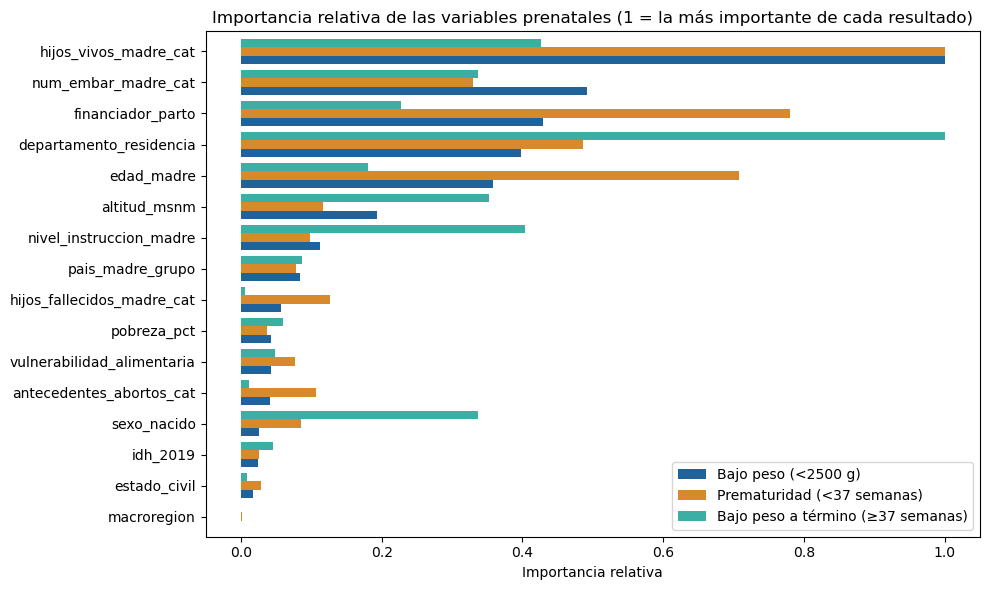

In [10]:
# 8. Importancia de cada variable prenatal para cada resultado (aumento del log loss al permutarla, 2025)
from sklearn.inspection import permutation_importance

importancias = {}
for resultado, (modelo_prenatal, partes) in prenatales.items():
    D_p, y_p, w_p = partes['pru']
    calculo = permutation_importance(modelo_prenatal, D_p[variables], y_p, sample_weight=w_p,
                                     scoring='neg_log_loss', n_repeats=3, random_state=42)
    importancias[resultado] = pd.Series(calculo.importances_mean, index=variables)
importancia = pd.DataFrame(importancias).sort_values('Bajo peso (<2500 g)', ascending=False)
print(importancia.to_string(float_format='{:.5f}'.format))

fig, ax = plt.subplots(figsize=(10, 6))
(importancia / importancia.max()).iloc[::-1].plot.barh(ax=ax, color=['#20639B', '#D8892B', '#3CAEA3'], width=0.8)
ax.set(title='Importancia relativa de las variables prenatales (1 = la más importante de cada resultado)',
       xlabel='Importancia relativa')
fig.tight_layout()
fig.savefig(figuras / 'importancia_por_resultado.png', dpi=180)
plt.show()

In [11]:
# 9. Descubrir perfiles de riesgo con un árbol de decisión interpretable para cada resultado
from sklearn.tree import DecisionTreeClassifier

ENTERAS = {'edad_madre', 'altitud_msnm'}


def texto_rango(variable, desde, hasta):
    if variable in ENTERAS:
        desde = None if desde is None else f'{np.ceil(desde):.0f}'
        hasta = None if hasta is None else f'{np.floor(hasta):.0f}'
        if desde and hasta:
            return f'{variable} {desde}-{hasta}'
        return f'{variable} ≥ {desde}' if desde else f'{variable} ≤ {hasta}'
    partes = ([f'{desde:.2f} <'] if desde is not None else []) + [variable] + \
             ([f'≤ {hasta:.2f}'] if hasta is not None else [])
    return ' '.join(partes)


def perfiles_arbol(partes):
    """Ajusta un árbol poco profundo y devuelve sus hojas como reglas con la tasa en 2015-2023 y 2025."""
    arbol = Pipeline([
        ('preparar', ColumnTransformer([
            ('numericas', SimpleImputer(strategy='median'), numericas),
            ('categorias', OneHotEncoder(handle_unknown='ignore'), categoricas),
        ], verbose_feature_names_out=False)),
        # Hojas con al menos 1 % de los nacimientos para que cada perfil sea relevante
        ('clasificar', DecisionTreeClassifier(max_depth=4, min_weight_fraction_leaf=0.01, random_state=42)),
    ])
    (D_e, y_e, w_e), (D_p, y_p, w_p) = partes['ent'], partes['pru']
    ajustar(arbol, D_e[variables], y_e, w_e)
    codificador = arbol['preparar'].named_transformers_['categorias']
    etiquetas = list(numericas) + [(columna, valor) for columna, valores in zip(categoricas, codificador.categories_)
                                   for valor in valores]
    nodos = arbol['clasificar'].tree_

    def reglas(nodo=0, limites=None, condiciones=()):
        limites = limites or {}
        if nodos.children_left[nodo] == -1:
            textos = [texto_rango(v, *rango) for v, rango in limites.items()] + list(condiciones)
            return {nodo: ' Y '.join(textos) or 'Todos'}
        izquierda, derecha = nodos.children_left[nodo], nodos.children_right[nodo]
        etiqueta, corte = etiquetas[nodos.feature[nodo]], nodos.threshold[nodo]
        if isinstance(etiqueta, str):
            desde, hasta = limites.get(etiqueta, (None, None))
            return {**reglas(izquierda, {**limites, etiqueta: (desde, corte)}, condiciones),
                    **reglas(derecha, {**limites, etiqueta: (corte, hasta)}, condiciones)}
        columna, valor = etiqueta
        return {**reglas(izquierda, limites, condiciones + (f'{columna} ≠ {valor}',)),
                **reglas(derecha, limites, condiciones + (f'{columna} = {valor}',))}

    def tasa_por_hoja(D, y, w):
        hoja = arbol['clasificar'].apply(arbol['preparar'].transform(D[variables]))
        tabla = pd.DataFrame({'hoja': hoja, 'n': w, 'casos': w * y}).groupby('hoja').sum()
        return tabla['n'], 100 * tabla['casos'] / tabla['n']

    n_e, tasa_e = tasa_por_hoja(D_e, y_e, w_e)
    n_p, tasa_p = tasa_por_hoja(D_p, y_p, w_p)
    perfiles = pd.DataFrame({'perfil': pd.Series(reglas()),
                             'nacimientos_2015_2023': n_e, '%_2015_2023': tasa_e.round(2),
                             'nacimientos_2025': n_p, '%_2025': tasa_p.round(2)})
    promedio = 100 * (w_e * y_e).sum() / w_e.sum()
    perfiles = perfiles.dropna(subset=['nacimientos_2015_2023']).sort_values('%_2015_2023', ascending=False)
    return arbol, perfiles, promedio


pd.set_option('display.max_colwidth', None)
arboles, perfiles = {}, {}
for resultado, (_, partes) in prenatales.items():
    arboles[resultado], perfiles[resultado], promedio = perfiles_arbol(partes)
    print(f'\n=== {resultado}: promedio 2015-2023 {promedio:.2f} %')
    print(perfiles[resultado].to_string(index=False))


=== Bajo peso (<2500 g): promedio 2015-2023 5.37 %
                                                                   perfil  nacimientos_2015_2023  %_2015_2023  nacimientos_2025  %_2025
                                                          edad_madre ≤ 15                62344.0         9.77            5874.0   11.58
           edad_madre ≥ 38 Y altitud_msnm ≥ 2543 Y sexo_nacido = FEMENINO                41781.0         9.20            4551.0    9.18
edad_madre 16-18 Y 0.25 < vulnerabilidad_alimentaria Y altitud_msnm ≤ 191                51427.0         8.90            5574.0   10.41
           edad_madre ≥ 38 Y altitud_msnm ≥ 2543 Y sexo_nacido ≠ FEMENINO                43369.0         8.28            4711.0    8.92
                                    edad_madre ≥ 42 Y altitud_msnm ≤ 2542                58933.0         7.97            6617.0    7.84
edad_madre 16-18 Y 0.25 < vulnerabilidad_alimentaria Y altitud_msnm ≥ 191               159918.0         7.42           12280.0    8

In [12]:
# 10. Guardar los modelos y sus métricas
import joblib

salida = raiz / 'modelos'
salida.mkdir(exist_ok=True)
joblib.dump({'modelo_bajo_peso_prenatal': candidatos[mejor], 'nombre': mejor, 'escenario': ESCENARIO_PRENATAL,
             'modelo_logistico': candidatos[mejor_logistica],
             'modelos_prenatales_por_resultado': {r: m for r, (m, _) in prenatales.items()},
             'arboles_perfiles': arboles, 'variables': variables,
             'entrenamiento': '2015-2023', 'validacion': 2024, 'prueba': 2025,
             'poblacion': 'partos únicos con peso y gestación válidos',
             'tabla_fuente': f'{catalogo}.curated.nacimientos_peru'},
            salida / 'modelo_bajo_peso.joblib')
metricas.to_csv(salida / 'metricas_2025.csv')
asociacion.to_csv(salida / 'matriz_asociacion.csv')
validacion.to_csv(salida / 'metricas_validacion_2024.csv', index=False)
por_capa.to_csv(salida / 'metricas_por_resultado_y_capa_2025.csv', index=False)
importancia.to_csv(salida / 'importancia_por_resultado.csv')
for resultado, tabla in perfiles.items():
    nombre = resultado.split(' (')[0].lower().replace(' ', '_').replace('é', 'e')
    tabla.to_csv(salida / f'perfiles_{nombre}.csv', index=False)
print('Modelos y métricas guardados en', salida.relative_to(raiz))
print('Uso educativo y retrospectivo; no es una herramienta clínica.')

Modelos y métricas guardados en modelos
Uso educativo y retrospectivo; no es una herramienta clínica.
